# Curious About the Titanic: My First Real-Data Project

Growing up, we all hear the story of the Titanic but as I started learning data analysis, I got curious about what the data could actually tell us about survival. Was it really "women and children first," or did class, age, and family size matter more?

This is my first project working with a messy, real world dataset. My goal isn't just to run code, but to ask meaningful questions and see what the data actually reveals.

## How I Approached My First Analysis
1. Understand the dataset
2. Explore the data
3. Clean the data
4. Engineer meaningful features
5. Analyze survival patterns
6. Visualize the findings
7. Summarize the key insights

## 1. Import Libraries

Pandas for data manipulation, NumPy for numerical operations, Matplotlib/Seaborn for visualization, SciPy for the chi-square test.

In [857]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay


## 2. Load and Understand the Dataset

I loaded the raw data from `data/raw/`, keeping it untouched so cleaning stays traceable, then checked its size, column types, and missing values to see what I was working with.

In [858]:
df = pd.read_csv("../data/raw/train.csv")
df.shape   

(891, 12)

In [859]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [860]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [861]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [862]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### What I Found

Most columns are complete, but `Age`, `Cabin`, and `Embarked` have missing values.

- **`Cabin`** : 687 missing (77% of the data). Too much to fill reliably; I'll likely drop it or turn it into a simpler "has cabin" flag instead.
- **`Age`** : about 20% missing. Since age matters for testing "women and children first," I want a smarter fill than just the average or maybe using passenger titles.
- **`Embarked`** : just 2 missing, easy to fill with the most common port.

*Next up: writing the cleaning steps to put these decisions into practice.*

## 3. Exploring Survival Patterns

Time to bring survival into the picture checking how it splits across class, sex, age, and family size, and whether the common story about that night actually holds up.

In [863]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [864]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [865]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [866]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [867]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [868]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [869]:
df.duplicated().sum()

np.int64(0)

In [870]:
df["PassengerId"].duplicated().sum()

np.int64(0)

In [871]:
df[["Age", "Fare", "SibSp", "Parch"]].describe()

,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [872]:
missing = df.isnull().sum()

In [873]:
missing_percentage = (missing / len(df)) * 100

pd.DataFrame({
    "Missing": missing,
    "Percentage": missing_percentage
}).sort_values("Missing", ascending=False)

,Missing,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


In [874]:
df.groupby("Pclass")["Cabin"].apply(lambda x: x.isnull().sum())

Pclass
1     40
2    168
3    479
Name: Cabin, dtype: int64

In [875]:
df.groupby("Pclass")["Age"].apply(lambda x: x.isnull().sum())

Pclass
1     30
2     11
3    136
Name: Age, dtype: int64

In [876]:
df.groupby("Sex")["Age"].apply(lambda x: x.isnull().sum())

Sex
female     53
male      124
Name: Age, dtype: int64

In [877]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [878]:
df["Age"].isnull().sum()

np.int64(177)

In [879]:
df["Age"].value_counts().sort_index().head(20)

Age
0.42      1
0.67      1
0.75      2
0.83      2
0.92      1
1.00      7
2.00     10
3.00      6
4.00     10
5.00      4
6.00      3
7.00      3
8.00      4
9.00      8
10.00     2
11.00     4
12.00     1
13.00     2
14.00     6
14.50     1
Name: count, dtype: int64

In [880]:
df.groupby("Pclass")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,186.0,38.233441,14.802856,0.92,27.0,37.0,49.0,80.0
2,173.0,29.877630,14.001077,0.67,23.0,29.0,36.0,70.0
3,355.0,25.140620,12.495398,0.42,18.0,24.0,32.0,74.0


In [881]:
df["Cabin"].value_counts().head(20)

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
F2             3
D              3
C22 C26        3
C123           2
D33            2
C52            2
B28            2
C83            2
F G73          2
D26            2
B58 B60        2
C2             2
E33            2
F4             2
D36            2
Name: count, dtype: int64

In [882]:
df["Cabin"].nunique()

147

In [883]:
df["Cabin"].notnull().sum()

np.int64(204)

In [884]:
df["Embarked"].value_counts(dropna=False)

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [885]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [886]:
df[df["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [887]:
df.loc[df["Embarked"].isnull(), ["PassengerId", "Pclass", "Name", "Sex", "Age", "Fare", "Cabin", "Embarked"]]

,PassengerId,Pclass,Name,Sex,Age,Fare,Cabin,Embarked
61,62,1,"Icard, Miss. Amelie",female,38.0,80.0,B28,NaN
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,80.0,B28,NaN


In [888]:
df.groupby("Cabin")["Survived"].mean().head(20)

Cabin
A10     0.0
A14     0.0
A16     1.0
A19     0.0
A20     1.0
A23     1.0
A24     0.0
A26     1.0
A31     1.0
A32     0.0
A34     1.0
A36     0.0
A5      0.0
A6      1.0
A7      0.0
B101    1.0
B102    0.0
B18     1.0
B19     0.0
B20     1.0
Name: Survived, dtype: float64

In [889]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [890]:
pd.crosstab(df["Pclass"], df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [891]:
pd.crosstab(df["Embarked"], df["Survived"])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


In [892]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [893]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [894]:
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

### Survival Rate by Sex

I started with sex, since "women and children first" is the most common story about that night worth testing first.

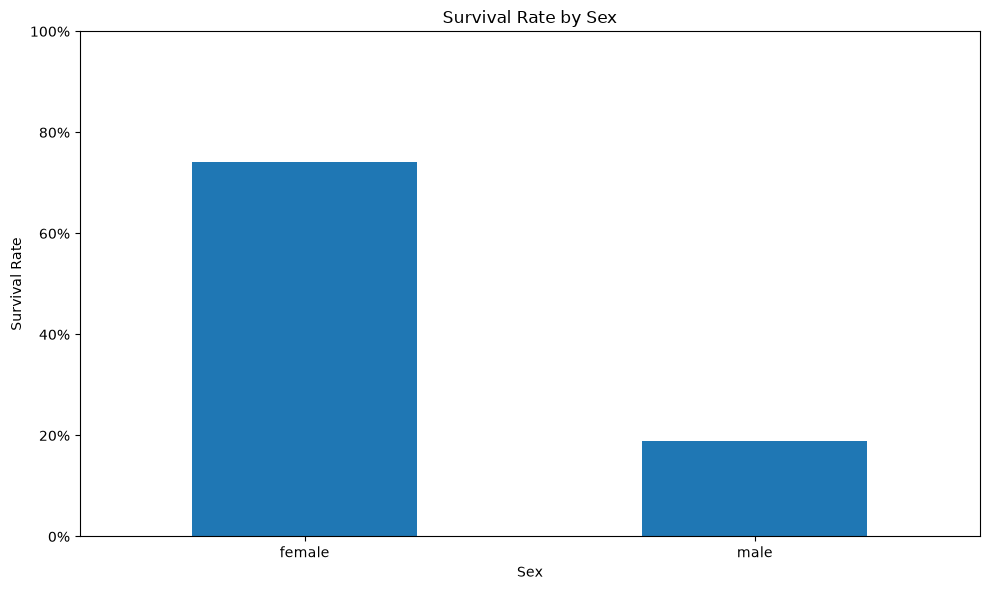

In [895]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()

survival_by_sex.plot(
    kind="bar",
    figsize=(10, 6),
    title="Survival Rate by Sex",
    ylabel="Survival Rate",
    xlabel="Sex"
)
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("../visuals/survival_rate_by_sex.png", dpi=300, bbox_inches="tight")
plt.show()

**What I noticed:** This is where the story actually shows up in the data female passengers survived at 74.2%, compared to just 18.9% for male passengers, making sex the strongest single pattern I found. But sex doesn't sit alone; class and other differences between men and women play into this too, which I dig into later.

### Survival Rate by Passenger Class

Next, I checked survival by passenger class.

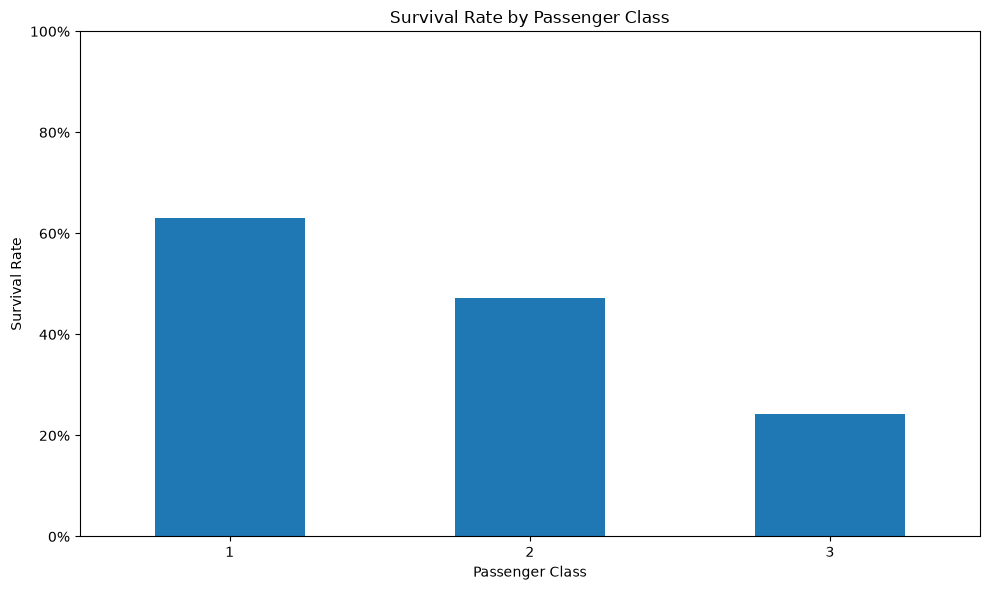

In [896]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()

survival_by_class.plot(
    kind="bar",
    figsize=(10, 6),
    title="Survival Rate by Passenger Class",
    ylabel="Survival Rate",
    xlabel="Passenger Class"
)
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("../visuals/survival_rate_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

**What I noticed:** The pattern was: 63.0% survival in 1st class, dropping to 47.3% in 2nd, and just 24.2% in 3rd. Money and status clearly bought a better chance of getting off that ship.

In [897]:
survival_by_sex_class = df.groupby(["Pclass", "Sex"])["Survived"].mean()

survival_by_sex_class

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

### Survival Rate by Sex and Passenger Class

After looking at sex and class separately, I combined them to see the full picture.

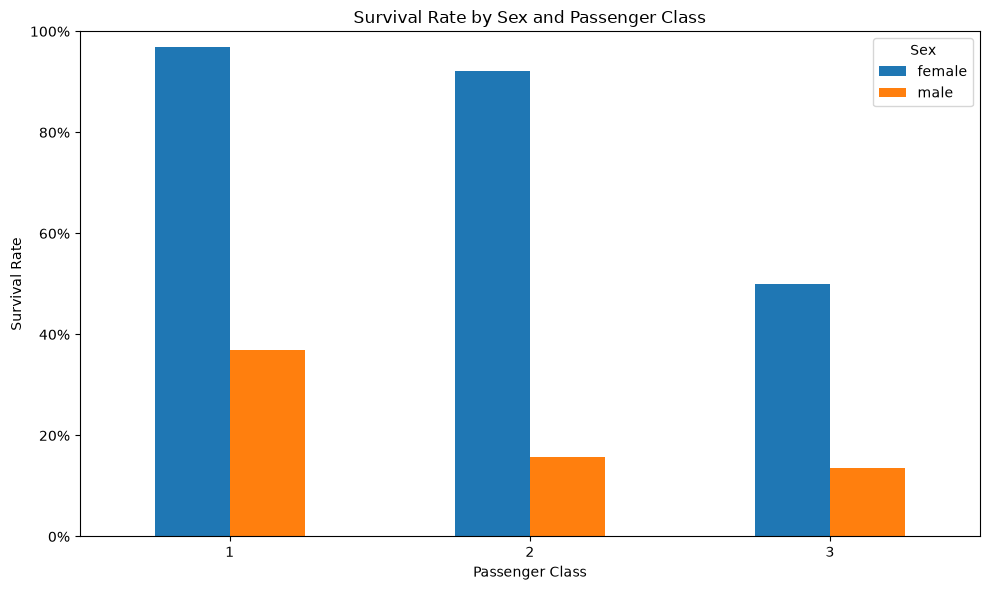

In [898]:
survival_by_sex_class = df.groupby(
    ["Pclass", "Sex"]
)["Survived"].mean().unstack()

ax=survival_by_sex_class.plot(
    kind="bar",
    figsize=(10, 6),
    title="Survival Rate by Sex and Passenger Class",
    ylabel="Survival Rate",
    xlabel="Passenger Class"
)

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../visuals/survival_rate_by_sex_class.png", dpi=300, bbox_inches="tight")
plt.show()

**What I noticed:** Together, they tell a sharper story than either alone. Women outsurvived men in every class, but class still mattered within each sex a 1st class woman had a very different outlook than a 3rd class woman, and the same split shows up for men. Survival here wasn't about one factor; it was about which combination of sex and class you happened to fall into.

In [899]:
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


In [900]:
df.groupby("Survived")["Age"].median()

Survived
0    28.0
1    28.0
Name: Age, dtype: float64

In [901]:
df.groupby(["Pclass", "Sex"])["Age"].median()

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [902]:
df.groupby(["Pclass", "Sex"])["Age"].agg(["count", "median", "mean"])

count  median       mean
Pclass Sex                             
1      female     85    35.0  34.611765
       male      101    40.0  41.281386
2      female     74    28.0  28.722973
       male       99    30.0  30.740707
3      female    102    21.5  21.750000
       male      253    25.0  26.507589

### Initial Observations

Survival clearly varies by sex and class. No duplicate rows or passenger IDs, so at least that's clean.

**Next up:** Handle the missing values, then build a few new features family size, travel status, title, and cabin location before going deeper.


## 4. Cleaning the Data

Time to fix the gaps. Working on a fresh copy of the dataset, I focused on the missing values in `Age`, `Embarked`, and `Cabin` since gaps like these could easily skew the survival analysis later on.

In [903]:
df_clean = df.copy()
df_clean["Age"] = df_clean["Age"].fillna(
    df_clean.groupby(["Pclass", "Sex"])["Age"].transform("median")
)

df_clean["Age"].isnull().sum()

np.int64(0)

In [904]:
df_clean[df_clean["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [905]:
df_clean["Embarked"].value_counts()
df_clean["Embarked"] = df_clean["Embarked"].fillna(
    df_clean["Embarked"].mode()[0]
)

In [906]:
df_clean["Embarked"].isnull().sum()

np.int64(0)

In [907]:
df_clean["Embarked"].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [908]:
df_clean["Deck"] = df_clean["Cabin"].str[0]
df_clean["Deck"].value_counts(dropna=False)

Deck
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64

In [909]:
df_clean["CabinKnown"] = df_clean["Cabin"].notna()
df_clean["CabinKnown"].value_counts()

CabinKnown
False    687
True     204
Name: count, dtype: int64

In [910]:
df_clean.groupby("CabinKnown")["Survived"].mean()

CabinKnown
False    0.299854
True     0.666667
Name: Survived, dtype: float64

In [911]:
df_clean.groupby("Deck")["Survived"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
Deck,,
D,33,0.757576
E,32,0.750000
B,47,0.744681
F,13,0.615385
C,59,0.593220
G,4,0.500000
A,15,0.466667
T,1,0.000000


In [912]:
df_clean.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Deck           687
CabinKnown       0
dtype: int64

In [913]:
df_clean["Deck"] = df_clean["Deck"].fillna("Unknown")
df_clean["Deck"].isnull().sum()

np.int64(0)

In [914]:
df_clean["Deck"].value_counts()

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

### Double Checking the Cleanup

With the cleaning done, I ran a final check missing values filled, passenger count still 891, and the new cabin variables looking right.

In [915]:
df_clean.shape

(891, 14)

In [916]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,CabinKnown
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Unknown,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Unknown,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Unknown,False


In [917]:
df_clean.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Deck             0
CabinKnown       0
dtype: int64

In [918]:
df_clean.to_csv("../data/processed/titanic_cleaned.csv", index=False)

### The cleaned dataset still holds all 891 passengers nothing got dropped in the process, and it's ready for feature engineering.

## 5. Feature Engineering

The raw columns only tell you so much on their own. I built a few new features: family size, travel status, title, and age groups to make these hidden patterns easier to work with.

### 5.1 Family Size

`FamilySize` = siblings/spouses + parents/children traveling with each passenger.

In [919]:
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean[["SibSp", "Parch", "FamilySize"]].head(10)

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


In [920]:
df_clean["FamilySize"].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [921]:
df_clean["FamilySize"].describe()

count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64

### 5.2 Is Alone

`IsAlone` flags passengers with no family aboard a simpler view than raw family size.

In [922]:
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)
df_clean["IsAlone"].value_counts()

IsAlone
1    537
0    354
Name: count, dtype: int64

In [923]:
df_clean[["FamilySize", "IsAlone"]].head(10) 

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


### 5.3 Passenger Title

Extracted the title (`Mr`, `Miss`, `Mrs`, `Master`, etc.) from each name it hints at social role and age in a way `Sex` and `Age` alone don't.

In [924]:
df_clean["Title"] = df_clean["Name"].str.extract(
  r",\s*([^.]*)\."
  )[0].str.strip()

In [925]:
df_clean["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

### 5.4 Title Group

Grouped the rare titles into a single `Rare` category keeps the feature usable without losing the fact that they stood out.

In [926]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

df_clean["TitleGroup"] = df_clean["Title"].where(
    df_clean["Title"].isin(common_titles),
    "Rare"
)

df_clean["TitleGroup"].value_counts()

TitleGroup
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

In [927]:
df_clean.groupby("TitleGroup")["Age"].agg(["count", "median", "mean"])

,count,median,mean
TitleGroup,,,
Master,40,4.0,6.616750
Miss,182,21.5,21.865385
Mr,517,28.0,31.339458
Mrs,125,35.0,34.804000
Rare,27,44.0,42.296296


### 5.5 Age Group

Grouped ages into broad bands (child, teen, adult, older) easier to compare survival across life stages than raw age alone.

In [928]:
df_clean["Age"].value_counts().sort_index().head(20)

Age
0.42      1
0.67      1
0.75      2
0.83      2
0.92      1
1.00      7
2.00     10
3.00      6
4.00     10
5.00      4
6.00      3
7.00      3
8.00      4
9.00      8
10.00     2
11.00     4
12.00     1
13.00     2
14.00     6
14.50     1
Name: count, dtype: int64

In [929]:
age_bins = [0, 12, 17, 30, 45, 60, float("inf")]
age_labels = ["Child", "Teen", "Young Adult", "Adult", "Older Adult", "Senior"]

df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [930]:
df_clean["AgeGroup"].value_counts().sort_index()

AgeGroup
Child           69
Teen            44
Young Adult    443
Adult          232
Older Adult     81
Senior          22
Name: count, dtype: int64

In [931]:
df_clean["AgeGroup"].isna().sum()

np.int64(0)

### Feature Engineering Validation

Checked the new features for sensible values still 891 passengers, now with more angles to explore survival from.

## 6. Survival Analysis

With the data cleaned and new features in place, it's time to answer the question that started this project — what actually determined who survived. Instead of looking at each factor alone, I focused on how they worked together.

### 6.1 Survival by Sex

In [932]:
df_clean.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [933]:
pd.crosstab(df_clean["Sex"], df_clean["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [934]:
df_clean.groupby("Sex")["Survived"].agg(["count", "mean"])

,count,mean
Sex,,
female,314,0.742038
male,577,0.188908


### 6.2 Survival by Passenger Class

In [935]:
df_clean.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [936]:
pd.crosstab(df_clean["Pclass"], df_clean["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


### 6.3 Survival by Traveling Alone

In [937]:
df_clean.groupby("IsAlone")["Survived"].mean() 

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

In [938]:
pd.crosstab(df_clean["IsAlone"], df_clean["Survived"])

Survived,0,1
IsAlone,,
0,175,179
1,374,163


In [939]:
df_clean.groupby(["Sex", "IsAlone"])["Survived"].mean()

Sex     IsAlone
female  0          0.712766
        1          0.785714
male    0          0.271084
        1          0.155718
Name: Survived, dtype: float64

In [940]:
pd.crosstab(
    [df_clean["Sex"], df_clean["IsAlone"]],
    df_clean["Survived"]
) 

Survived          0    1
Sex    IsAlone          
female 0         54  134
       1         27   99
male   0        121   45
       1        347   64

In [941]:
df_clean.groupby(["Pclass", "IsAlone"])["Survived"].mean()

Pclass  IsAlone
1       0          0.728972
        1          0.532110
2       0          0.637500
        1          0.346154
3       0          0.299401
        1          0.212963
Name: Survived, dtype: float64

In [942]:
pd.crosstab(
    [df_clean["Pclass"], df_clean["IsAlone"]],
    df_clean["Survived"]
)

Survived          0   1
Pclass IsAlone         
1      0         29  78
       1         51  58
2      0         29  51
       1         68  36
3      0        117  50
       1        255  69

### 6.4 Survival by Family Size

In [943]:
df_clean.groupby("FamilySize")["Survived"].agg(["count", "mean"])

,count,mean
FamilySize,,
1,537,0.303538
2,161,0.552795
3,102,0.578431
4,29,0.724138
5,15,0.200000
6,22,0.136364
7,12,0.333333
8,6,0.000000
11,7,0.000000


In [944]:
df_clean.groupby(["Pclass", "FamilySize"])["Survived"].agg(["count", "mean"])

count      mean
Pclass FamilySize                 
1      1             109  0.532110
       2              70  0.728571
       3              24  0.750000
       4               7  0.714286
       5               2  1.000000
       6               4  0.500000
2      1             104  0.346154
       2              34  0.529412
       3              31  0.677419
       4              13  0.769231
       5               1  1.000000
       6               1  1.000000
3      1             324  0.212963
       2              57  0.350877
       3              47  0.425532
       4               9  0.666667
       5              12  0.000000
       6              17  0.000000
       7              12  0.333333
       8               6  0.000000
       11              7  0.000000

### 6.5 Survival by Age

In [945]:
df_clean["Age"].describe() 

count    891.000000
mean      29.112424
std       13.304424
min        0.420000
25%       21.500000
50%       26.000000
75%       36.000000
max       80.000000
Name: Age, dtype: float64

In [946]:
df_clean.groupby("Survived")["Age"].agg(["count", "median", "mean"])

,count,median,mean
Survived,,,
0,549,25.0,29.737705
1,342,27.0,28.108684


In [947]:
df_clean.groupby(
    "AgeGroup",
    observed=True
)["Survived"].agg(["count", "mean"])

,count,mean
AgeGroup,,
Child,69,0.579710
Teen,44,0.477273
Young Adult,443,0.322799
Adult,232,0.431034
Older Adult,81,0.407407
Senior,22,0.227273


In [948]:
df_clean.groupby(
    ["AgeGroup", "Sex"],
    observed=True
)["Survived"].agg(["count", "mean"])

count      mean
AgeGroup    Sex                    
Child       female     32  0.593750
            male       37  0.567568
Teen        female     23  0.826087
            male       21  0.095238
Young Adult female    147  0.700680
            male      296  0.135135
Adult       female     82  0.804878
            male      150  0.226667
Older Adult female     27  0.851852
            male       54  0.185185
Senior      female      3  1.000000
            male       19  0.105263

### 6.6 Survival by Title

In [949]:
df_clean.groupby(
    "TitleGroup"
)["Survived"].mean().sort_values(ascending=False)

TitleGroup
Mrs       0.792000
Miss      0.697802
Master    0.575000
Rare      0.444444
Mr        0.156673
Name: Survived, dtype: float64

In [950]:
pd.crosstab(df_clean["TitleGroup"], df_clean["Survived"]) 

Survived,0,1
TitleGroup,,
Master,17,23
Miss,55,127
Mr,436,81
Mrs,26,99
Rare,15,12


In [951]:
df_clean.groupby("TitleGroup")["Age"].agg(
    ["count", "median", "mean"]
)

,count,median,mean
TitleGroup,,,
Master,40,4.0,6.616750
Miss,182,21.5,21.865385
Mr,517,28.0,31.339458
Mrs,125,35.0,34.804000
Rare,27,44.0,42.296296


### 6.7 Survival by Cabin Information

In [952]:
df_clean.groupby("CabinKnown")["Survived"].mean()

CabinKnown
False    0.299854
True     0.666667
Name: Survived, dtype: float64

In [953]:
pd.crosstab(df_clean["CabinKnown"], df_clean["Survived"]) 

Survived,0,1
CabinKnown,,
False,481,206
True,68,136


In [954]:
df_clean.groupby("Deck")["Survived"].mean()

Deck
A          0.466667
B          0.744681
C          0.593220
D          0.757576
E          0.750000
F          0.615385
G          0.500000
T          0.000000
Unknown    0.299854
Name: Survived, dtype: float64

### 6.8 Survival by Embarkation

In [955]:
df_clean.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

## 7. Visualizations

Numbers only tell you so much charts make the patterns from the survival analysis easier to actually see. Rather than plotting every calculation, I picked the relationships that mattered most.

### Survival Rate by Sex

This is where "women and children first" actually shows up in the data a huge gap in survival between female and male passengers, making sex the strongest pattern I found.

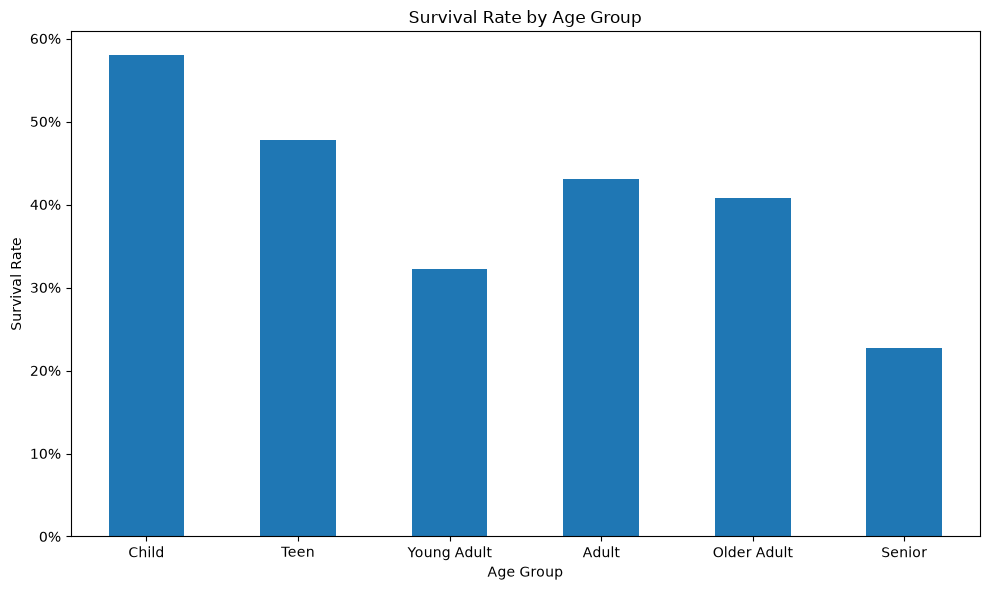

In [956]:
survival_by_age = df_clean.groupby(
    "AgeGroup", observed=True
)["Survived"].mean()

plt.figure(figsize=(10, 6))

survival_by_age.plot(
    kind="bar",
    title="Survival Rate by Age Group",
    ylabel="Survival Rate",
    xlabel="Age Group"
)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**What I noticed:** Family size didn't have a simple straight-line effect on survival. Solo travelers had lower survival, small families did better, and very large families dropped off sharply though those groups were small enough that the pattern should be read with some caution.

### Survival Rate by Family Size

I wanted to see if traveling with more people helped or hurt your odds.

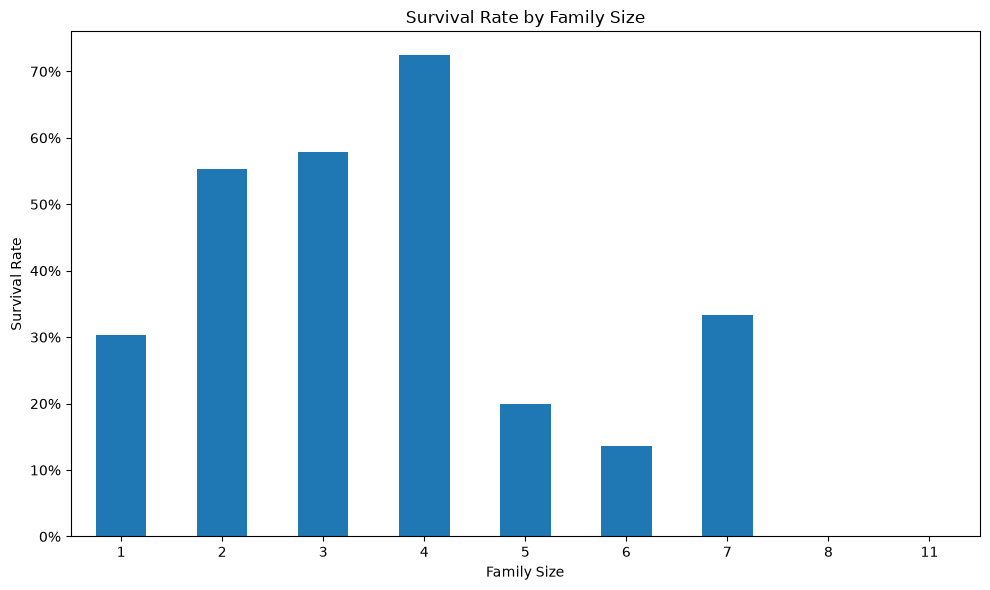

In [957]:
survival_by_family_size = df_clean.groupby("FamilySize")["Survived"].mean()

plt.figure(figsize=(10, 6))

survival_by_family_size.plot(
    kind="bar",
    title="Survival Rate by Family Size",
    ylabel="Survival Rate",
    xlabel="Family Size"
)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_family_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**What I noticed:** Family size didn't have a simple straight line effect on survival. Solo travelers had lower survival, small families did better, and very large families dropped off sharply though those groups were small enough that the pattern should be read with some caution.

### Survival Rate by Cabin Information

With so much cabin data missing, I couldn't treat it as a normal column so instead I checked whether just *having* a recorded cabin made a difference, regardless of which one.

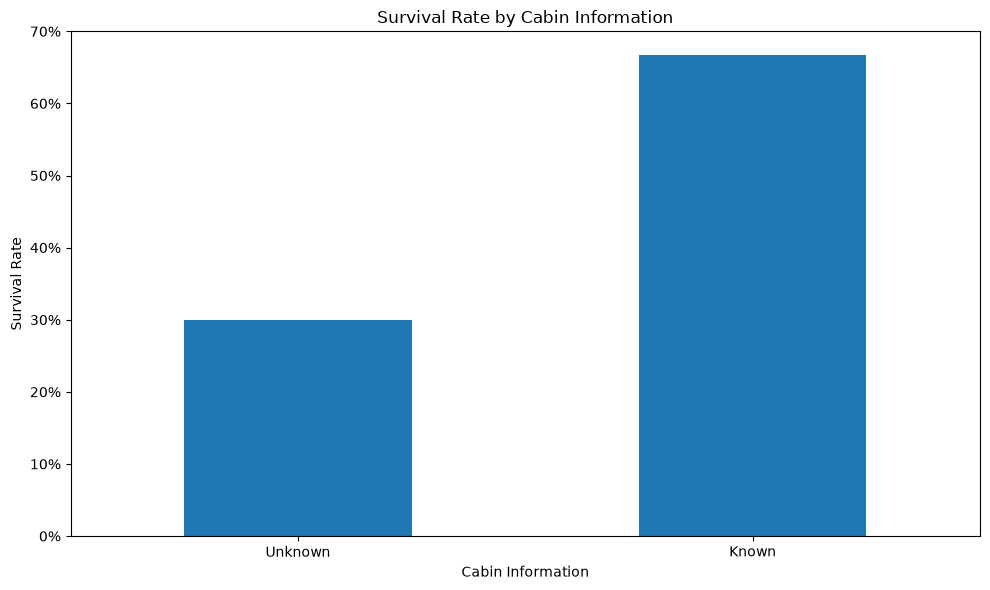

In [958]:
survival_by_cabin = df_clean.groupby("CabinKnown")["Survived"].mean()

plt.figure(figsize=(10, 6))

survival_by_cabin.plot(
    kind="bar",
    title="Survival Rate by Cabin Information",
    ylabel="Survival Rate",
    xlabel="Cabin Information"
)

plt.xticks([0, 1], ["Unknown", "Known"], rotation=0)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_cabin_known.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**What I noticed:** Passengers with a recorded cabin survived at noticeably higher rates than those without one. That's probably picking up on class or location rather than the cabin itself but with so much missing, it's worth treating this pattern as a lead, not a conclusion.

### Survival Rate by Deck

Once I pulled the deck out of the cabin data, I checked whether survival rates across the available decks to see whether cabin info existed, but where specifically.

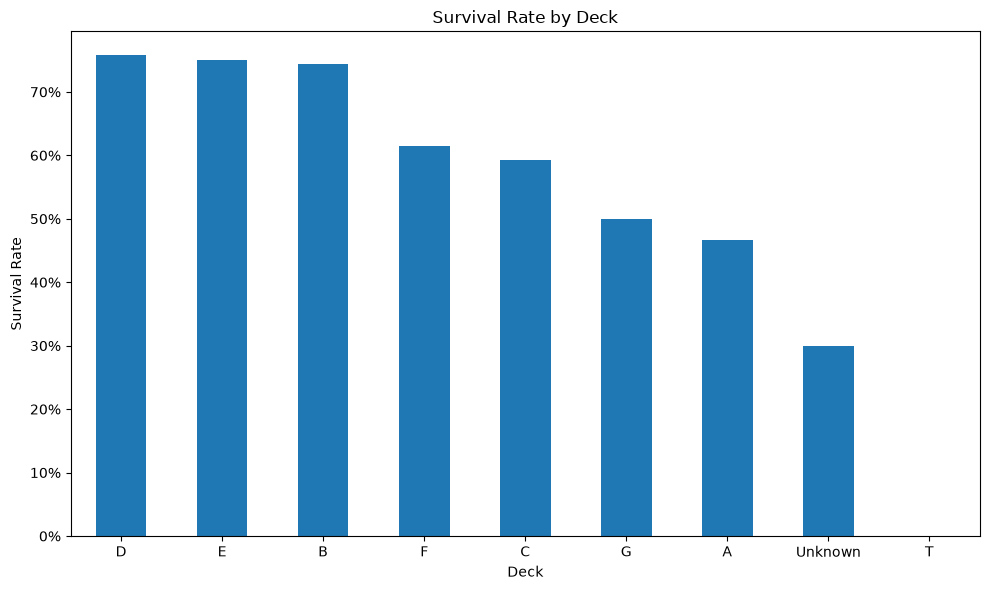

In [959]:
survival_by_deck = df_clean.groupby("Deck")["Survived"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

survival_by_deck.plot(
    kind="bar",
    title="Survival Rate by Deck",
    ylabel="Survival Rate",
    xlabel="Deck"
)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_deck.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**What I noticed:** Survival did vary across decks, but this builds on a small, incomplete slice of the data most passengers had no cabin info at all, so I'm treating this more as a curiosity than a solid finding.

### Survival Rate by Port of Embarkation

I checked whether where passengers boarded made any difference to survival.

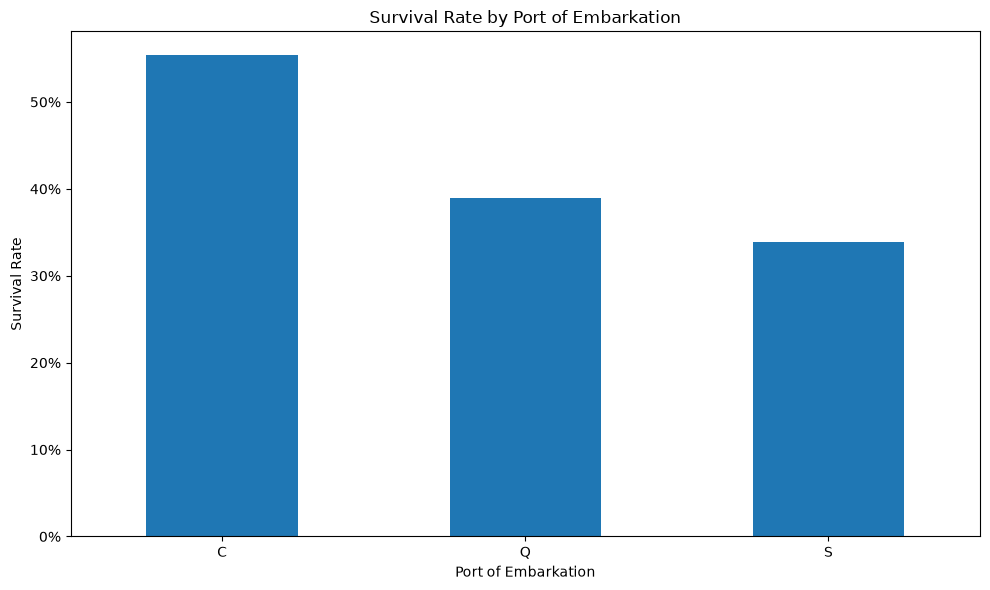

In [960]:
survival_by_embarked = df_clean.groupby("Embarked")["Survived"].mean()

plt.figure(figsize=(10, 6))

survival_by_embarked.plot(
    kind="bar",
    title="Survival Rate by Port of Embarkation",
    ylabel="Survival Rate",
    xlabel="Port of Embarkation"
)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_embarked.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**What I noticed:** Cherbourg had the highest survival rate, then Queenstown, with Southampton the lowest. But port probably isn't the real cause it likely just reflects who tended to board from where, in terms of class and other factors.

### Survival Rate by Title Group

I pulled titles out of passenger names, grouping the rarer ones into "Rare," to see if they revealed anything beyond what sex and class already showed.

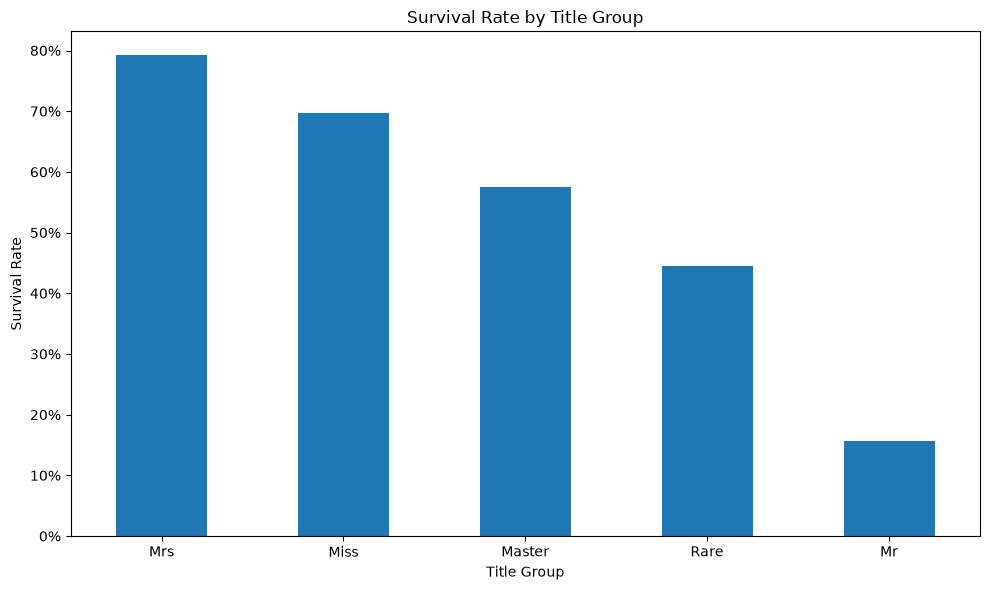

In [961]:
survival_by_title = df_clean.groupby("TitleGroup")["Survived"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

survival_by_title.plot(
    kind="bar",
    title="Survival Rate by Title Group",
    ylabel="Survival Rate",
    xlabel="Title Group"
)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_title_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**What I noticed:** Survival differed a lot by title: Mrs and Miss did best, Mr much worse. But titles are really just standing in for sex, age, and status, so this isn't a separate cause of its own.

### Survival Rate by Age Group and Sex

Age showed different patterns on its own, so I combined it with sex to see if the relationship held up across both.

<Figure size 1000x600 with 0 Axes>

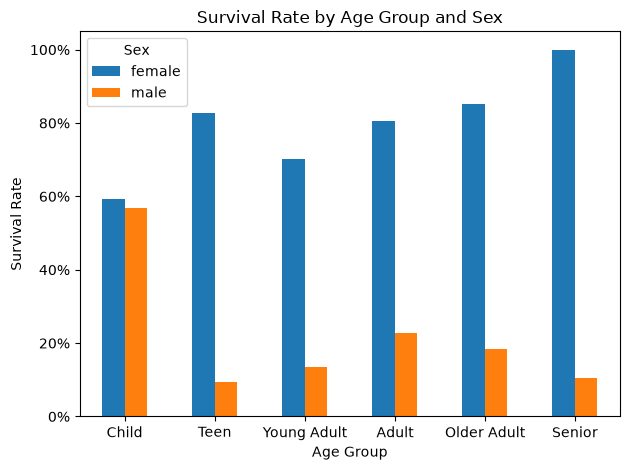

In [962]:
survival_by_age_sex = df_clean.groupby(
    ["AgeGroup", "Sex"], observed=True
)["Survived"].mean().unstack()

plt.figure(figsize=(10, 6))

survival_by_age_sex.plot(
    kind="bar",
    title="Survival Rate by Age Group and Sex",
    ylabel="Survival Rate",
    xlabel="Age Group"
)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_age_and_sex.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**What I noticed:** The female & male survival gap stayed strong across almost every age group. Age alone doesn't explain the pattern sex and age are working together here, not separately.

### Survival Rate by Sex and Travel Status

I combined sex with travel status to see whether traveling alone affected men and women differently.

<Figure size 800x500 with 0 Axes>

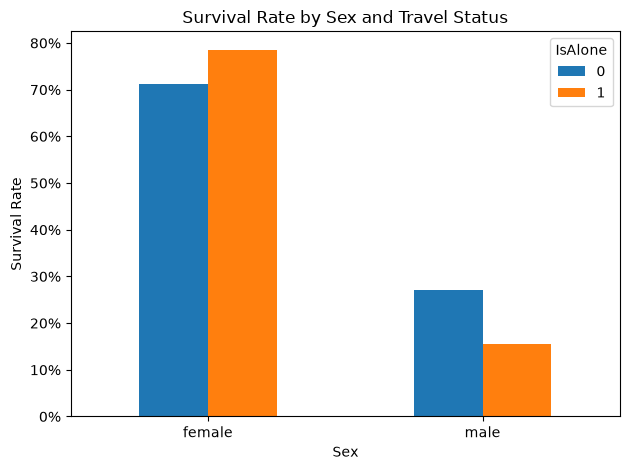

In [963]:
survival_by_sex_alone = df_clean.groupby(
    ["Sex", "IsAlone"]
)["Survived"].mean().unstack()

plt.figure(figsize=(8, 5))

survival_by_sex_alone.plot(
    kind="bar",
    title="Survival Rate by Sex and Travel Status",
    ylabel="Survival Rate",
    xlabel="Sex"
)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_sex_and_alone.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**What I noticed:** Being alone affected men and women differently it wasn't the same penalty (or benefit) for both. That gap is a clearer sign that family status and sex need to be read together, not separately.

### Survival Rate by Passenger Class and Family Size

Last combination: class and family size together, to see if family size mattered the same way for everyone or only in certain classes.

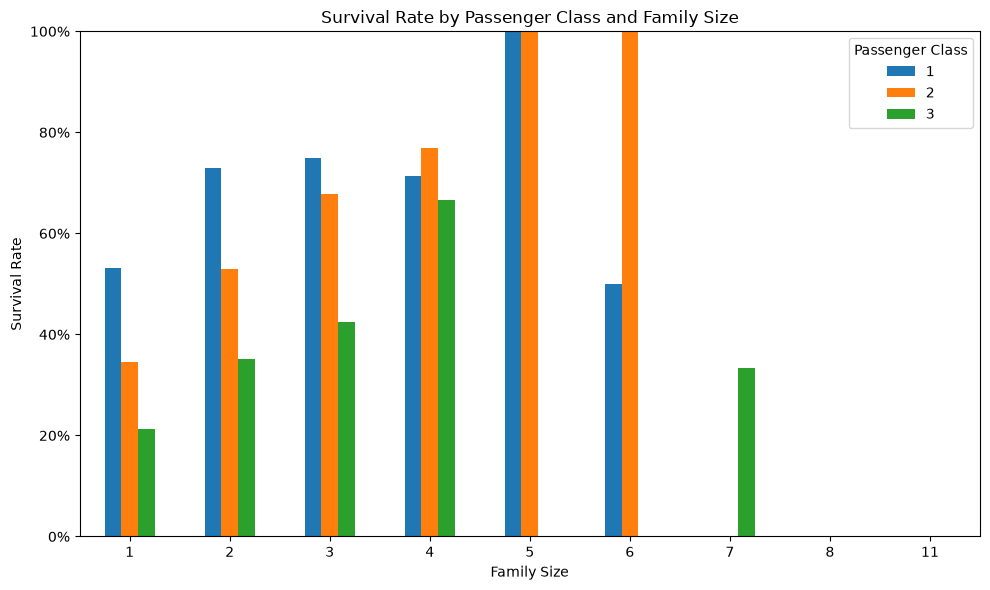

In [964]:
pclass_family = df_clean.pivot_table(
    values="Survived",
    index="FamilySize",
    columns="Pclass",
    aggfunc="mean"
)

pclass_family.plot(
    kind="bar",
    figsize=(10, 6),
    title="Survival Rate by Passenger Class and Family Size",
    ylabel="Survival Rate",
    xlabel="Family Size"
)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Passenger Class")
plt.tight_layout()

plt.savefig(
    "../visuals/survival_rate_by_class_and_family_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**What I noticed:** Describe the actual pattern[ e.g., "Small families did better than solo travelers in every class, but the boost was much bigger in 1st class than in 3rd" or whatever you actually found ]. Class changes how family size plays out another case where looking at one feature alone would've missed the real picture.

## 8. Statistical Analysis

Charts show differences, but not whether they're real or just noise. I used the chi-square test to check whether these relationships were likely real, or just noise from a relatively small dataset.

### 8.1 Sex and Survival

In [965]:
contingency_sex = pd.crosstab(df["Sex"], df["Survived"])

contingency_sex

Survived,0,1
Sex,,
female,81,233
male,468,109


#### Hypotheses

- **H₀ (Null Hypothesis):** Sex has no real relationship with survival any difference I saw is just noise.
- **H₁ (Alternative Hypothesis):** Sex and survival are actually connected.

Testing at the standard 0.05 significance level.

In [966]:
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_sex
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 260.71702016732104
p-value: 1.1973570627755645e-58
Degrees of freedom: 1


#### Interpretation

The chi square test shows a statistically significant association between sex and survival (p < 0.05). This supports the difference observed during exploratory analysis, but doesn't imply causation.

#### Expected Frequencies

This shows what the numbers would look like if sex and survival had no real connection, as a baseline to compare against.

In [967]:
expected_sex = pd.DataFrame(
    expected,
    index=contingency_sex.index,
    columns=contingency_sex.columns
)

expected_sex

Survived,0,1
Sex,,
female,193.474747,120.525253
male,355.525253,221.474747


#### Effect Size

Cramer's V: [X] which is a [weak/moderate/strong] effect. Sex isn't just statistically linked to survival; it's a real factor.

In [968]:
cramers_v = association(
    contingency_sex,
    method="cramer"
)

print("Cramer's V:", cramers_v)

Cramer's V: 0.5433513806577551


### 8.2 Passenger Class and Survival

In [969]:
contingency_class = pd.crosstab(df["Pclass"], df["Survived"])
contingency_class

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


#### Hypotheses

- **H₀:** Passenger class and survival are independent.
- **H₁:** Passenger class and survival are associated.

Testing at the 0.05 significance level.

In [970]:
chi2_class, p_value_class, degrees_of_freedom_class, expected_class = chi2_contingency(
    contingency_class
)

print("Chi-square statistic:", chi2_class)
print("p-value:", p_value_class)
print("Degrees of freedom:", degrees_of_freedom_class)

Chi-square statistic: 102.88898875696056
p-value: 4.549251711298793e-23
Degrees of freedom: 2


#### Interpretation

Passenger class and survival are statistically associated (p < 0.05). This supports the differences in survival rates observed during exploratory analysis.

#### Effect Size

Cramer's V: [X] : a [weak/moderate/strong] effect. It measures the strength of the association between passenger class and survival.

In [971]:
cramers_v_class = association(
    contingency_class,
    method="cramer"
)

print("Cramer's V:", cramers_v_class)

Cramer's V: 0.33981738800531175


## 9. Baseline Machine Learning Model

With the exploration and testing done, it's time to see if a model can actually predict survival not just describe the patterns, but use them.

In [972]:
X = df_clean[
    ["Pclass", "Sex", "Age", "Fare", "FamilySize", "IsAlone"]
].copy()

y = df_clean["Survived"]

X.head(), y.head()

(   Pclass     Sex   Age     Fare  FamilySize  IsAlone
 0       3    male  22.0   7.2500           2        0
 1       1  female  38.0  71.2833           2        0
 2       3  female  26.0   7.9250           1        1
 3       1  female  35.0  53.1000           2        0
 4       3    male  35.0   8.0500           1        1,
 0    0
 1    1
 2    1
 3    1
 4    0
 Name: Survived, dtype: int64)

In [973]:
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})

X.head()

,Pclass,Sex,Age,Fare,FamilySize,IsAlone
0,3,0,22.0,7.2500,2,0
1,1,1,38.0,71.2833,2,0
2,3,1,26.0,7.9250,1,1
3,1,1,35.0,53.1000,2,0
4,3,0,35.0,8.0500,1,1


In [974]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (712, 6)
Test set: (179, 6)


In [975]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [976]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0])

In [977]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8156424581005587


In [978]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [979]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[96 14]
 [19 50]]


In [980]:
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.8461133069828722


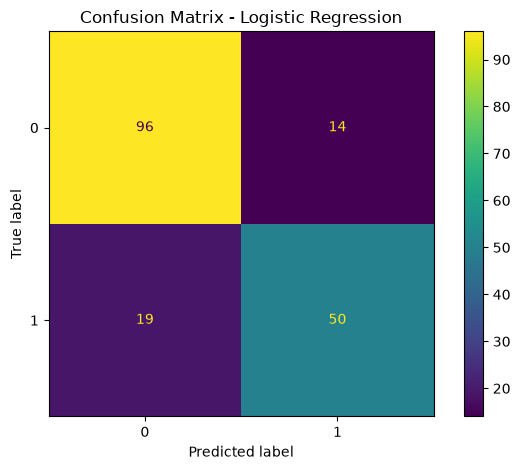

In [981]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [982]:
plt.savefig(
    "../visuals/survival_analysis/confusion_matrix_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

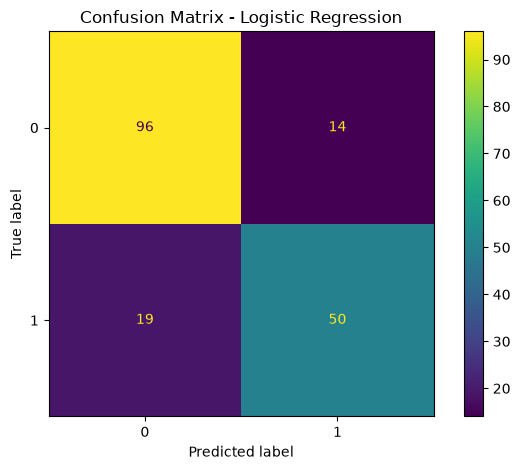

In [983]:
fig, ax = plt.subplots()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)

ax.set_title("Confusion Matrix - Logistic Regression")

fig.tight_layout()
fig.savefig(
    "../visuals/survival_analysis/confusion_matrix_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Findings

**Sex** was the strongest factor 74.2% of female passengers survived vs. 18.9% of male, a statistically significant, strong effect (Cramer's V = 0.543).

**Passenger class** came in close behind survival dropped from 63.0% (1st) to 24.2% (3rd), a significant, moderate effect (Cramer's V = 0.340).

**Family size and age** didn't follow simple patterns solo travelers survived less than small family groups, and the sex gap held up across most age groups.

**Cabin information** showed at a real difference, but with 77.1% missing data, it's a lead worth exploring, not a solid conclusion.

**The baseline Logistic Regression model** hit 81.56% accuracy and a ROC-AUC of 0.846 better at catching non-survivors (F1 = 0.85) than survivors (F1 = 0.75), correctly identifying 72% of actual survivors.

Overall, sex and class mattered most throughout the analysis, and the baseline model shows these patterns are strong enough to actually predict survival, not just describe it.

## 10. Conclusion

This project took me from spotting patterns in charts, to testing whether those patterns held up statistically, to finally building a model that uses them to actually predict survival.

Sex and class were the strongest, most reliable patterns throughout confirmed by the statistical tests and backed up by a model that hit 81.56% accuracy and a ROC-AUC of 0.846. Other factors were shakier: cabin data was too incomplete to trust fully, and family size and age never followed a clean, simple trend.

The biggest lesson: good analysis moves from **observation → evidence → prediction** and at every step, it's worth asking whether you're looking at a real signal or just noise, and never confusing association with causation.